In [7]:
import os

DATA_PATH = "/Users/kamy/Desktop/4371 sec/KDDTrain+.txt"
OUTPUT_DIR = "/Users/kamy/Desktop/4371 sec/results"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("File exists:", os.path.exists(DATA_PATH))

File exists: True


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [11]:
TOP_FEATURES = [
    "src_bytes", "dst_bytes", "flag", "logged_in",
    "same_srv_rate", "diff_srv_rate", "serror_rate", "count"
]

NSL_KDD_COLS = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root",
    "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds",
    "is_host_login", "is_guest_login", "count", "srv_count",
    "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
    "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
    "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label", "difficulty"
]

In [13]:
df = pd.read_csv(DATA_PATH, header=None, names=NSL_KDD_COLS)
df = df.drop(columns=["difficulty"])

print("Total records:", len(df))
print("Normal:", (df["label"] == "normal").sum())
print("Attack:", (df["label"] != "normal").sum())

df.head()

Total records: 125973
Normal: 67343
Attack: 58630


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [15]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

le = LabelEncoder()
df["flag"] = le.fit_transform(df["flag"].astype(str))

# Binary classification: normal=0, attack=1
df["label"] = (df["label"].str.lower() != "normal").astype(int)

X = df[TOP_FEATURES].values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train samples:", len(X_train))
print("Test samples:", len(X_test))

Train samples: 88181
Test samples: 37792


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Neural Network
nn_model = MLPClassifier(
    hidden_layer_sizes=(64,),
    activation="relu",
    solver="adam",
    max_iter=200,
    early_stopping=True
)
nn_model.fit(X_train, y_train)

print("Models trained ✅")

Models trained ✅


In [21]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt

def evaluate(model, name):
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred) * 100
    prec = precision_score(y_test, y_pred) * 100
    rec  = recall_score(y_test, y_pred) * 100
    f1   = f1_score(y_test, y_pred) * 100

    print(f"\n{name}")
    print(f"Accuracy: {acc:.2f}%")
    print(f"Precision: {prec:.2f}%")
    print(f"Recall: {rec:.2f}%")
    print(f"F1 Score: {f1:.2f}%")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


Logistic Regression
Accuracy: 87.16%
Precision: 90.49%
Recall: 80.93%
F1 Score: 85.44%

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.93      0.89     20203
           1       0.90      0.81      0.85     17589

    accuracy                           0.87     37792
   macro avg       0.88      0.87      0.87     37792
weighted avg       0.87      0.87      0.87     37792



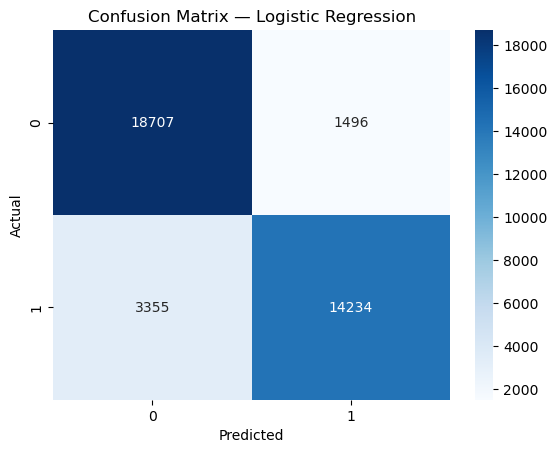


Neural Network
Accuracy: 92.05%
Precision: 98.99%
Recall: 83.77%
F1 Score: 90.74%

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93     20203
           1       0.99      0.84      0.91     17589

    accuracy                           0.92     37792
   macro avg       0.93      0.92      0.92     37792
weighted avg       0.93      0.92      0.92     37792



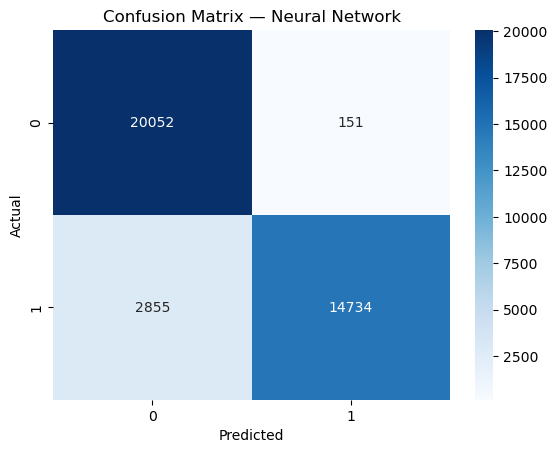

In [23]:
evaluate(lr_model, "Logistic Regression")
evaluate(nn_model, "Neural Network")

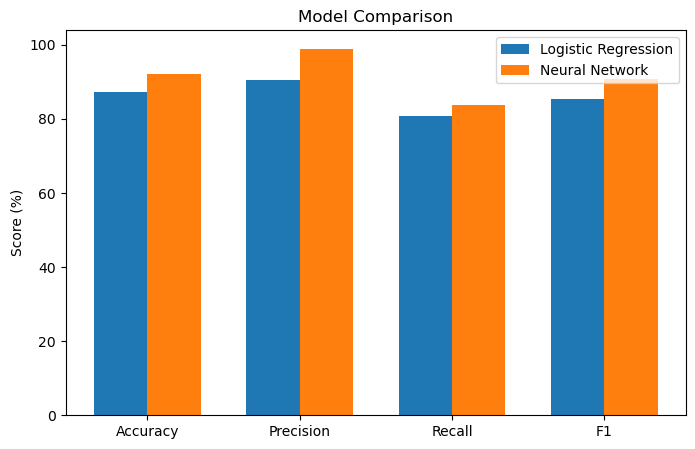

In [25]:
metrics = ["Accuracy", "Precision", "Recall", "F1"]
lr_scores = []
nn_scores = []

# collect scores
def get_scores(model):
    y_pred = model.predict(X_test)
    return [
        accuracy_score(y_test, y_pred)*100,
        precision_score(y_test, y_pred)*100,
        recall_score(y_test, y_pred)*100,
        f1_score(y_test, y_pred)*100
    ]

lr_scores = get_scores(lr_model)
nn_scores = get_scores(nn_model)

import numpy as np

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, lr_scores, width, label="Logistic Regression")
plt.bar(x + width/2, nn_scores, width, label="Neural Network")

plt.xticks(x, metrics)
plt.ylabel("Score (%)")
plt.title("Model Comparison")
plt.legend()
plt.show()

In [27]:
samples = [
    ("Normal browsing", [2345, 8901, 10, 1, 0.95, 0.02, 0.00, 3]),
    ("DoS attack",      [0, 0, 8, 0, 1.00, 0.00, 1.00, 511]),
    ("Port scan",       [0, 0, 5, 0, 0.02, 0.98, 0.00, 1]),
    ("Normal DNS",      [0, 146, 10, 1, 0.08, 0.15, 0.00, 13])
]

for desc, feat in samples:
    feat_scaled = scaler.transform([feat])
    
    lr_pred = lr_model.predict(feat_scaled)[0]
    nn_pred = nn_model.predict(feat_scaled)[0]
    
    print(f"\n{desc}")
    print("Logistic Regression:", "ATTACK" if lr_pred else "NORMAL")
    print("Neural Network:", "ATTACK" if nn_pred else "NORMAL")


Normal browsing
Logistic Regression: NORMAL
Neural Network: NORMAL

DoS attack
Logistic Regression: ATTACK
Neural Network: ATTACK

Port scan
Logistic Regression: ATTACK
Neural Network: ATTACK

Normal DNS
Logistic Regression: NORMAL
Neural Network: NORMAL
